# AmBe NPE test
Modifying NPE example from sbi tutorial notebook which does the following:

This example attempts to infer 3 unknown parameters from a 20-dimensional 1D data vector using amortized posterior inference. We train the models from a simple synthetic catalog. This tutorial mirrors the same configuration as in [examples/toy_sbi.py](../examples/toy_sbi.py), but demonstrates how one would interact with the inference pipeline in a jupyter notebook.

Pueh Leng Tan, 6 March 2026

In [1]:
%load_ext autoreload
%autoreload 2

# ignore warnings for readability
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn as nn

import ili
from ili.dataloaders import NumpyLoader
from ili.inference import InferenceRunner
from ili.validation.metrics import PosteriorCoverage, PlotSinglePosterior

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
print(f'Able to see {torch.cuda.device_count()} GPUs')

2026-03-06 14:46:03.733943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772826363.753684  258280 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772826363.759789  258280 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-06 14:46:03.781704: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Device: cuda
Able to see 6 GPUs


## Data stage

In [ ]:
# create synthetic catalog
def simulator(params):
    # create toy simulations, returns (10,) array
    x = np.arange(10)
    y = 3 * params[0] * np.sin(x) + params[1] * x ** 2 - 2 * params[2] * x
    y += np.random.randn(len(x))
    return y

num_sim = 400
seed_sim = 12345
np.random.seed(seed_sim)
theta = np.random.rand(num_sim, 3)  # num_sim simulations, 3 parameters, (num_sim, 3) array
x = np.array([simulator(t) for t in theta]) # (num_sim, 10) array

# make a dataloader
loader = NumpyLoader(x=x, theta=theta)

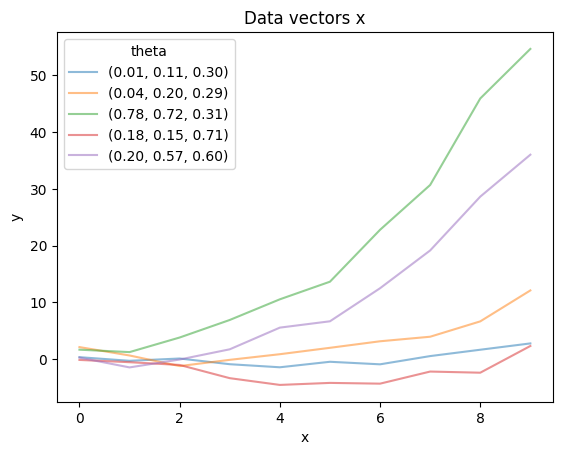

In [3]:
# plot some examples of the data
fig, ax = plt.subplots()
for i in range(5):
    ind = np.random.randint(len(theta))
    ax.plot(x[ind], alpha=0.5, label=f'(%.2f, %.2f, %.2f)' % tuple(theta[ind]))
ax.legend(title='theta')
ax.set_title('Data vectors x')
ax.set_xlabel('x') # actually just np.arange(10)
ax.set_ylabel('y') # 3 A sin(x) + B x^2 - 2 C x + noise, (A, B, C) = theta
plt.show()

The SBIRunner object will handle all of the data normalization and model training for us. We just need to provide it with:
- our parameter prior
- our inference type (SNPE/SNLE/SNRE)
- our desired neural network architecture
- our training hyperparameters

On the backend, it does a validation split among the provided training data, trains the neural networks with an Adam optimizer, and enforces an early stopping criterion to prevent overfitting. All the parameters of these processes can be independently configured.

## Inference stage

In [4]:
# define a prior
prior = ili.utils.Uniform(low=[0, 0, 0], high=[1, 1, 1], device=device)

# instantiate your neural networks to be used as an ensemble
repeats_maf = 2 # number of times you wanna repeat a NN with this architecture in the ensemble

# available architectures are mdn, maf, nsf, made, linear, mlp, resnet.
nets = [
    ili.utils.load_nde_sbi(engine='NPE', model='maf', hidden_features=50, num_transforms=5, repeats = repeats_maf),
    ili.utils.load_nde_sbi(engine='NPE', model='mdn', hidden_features=50, num_components=6)
]

# define training arguments
train_args = {
    'training_batch_size': 32,
    'learning_rate': 1e-4
}

# initialize the trainer
runner = InferenceRunner.load(
    backend='sbi',
    engine='NPE',
    prior=prior,
    nets=nets,
    device=device,
    train_args=train_args,
    proposal=None,
    out_dir=None
)

In [5]:
# This prior object is some ili object. You can sample from it as follows.
# It'll defo have 3 columns cause there are 3 parameters
# And the number of rows (pseudo-experiments) is the number inside this torch.Size.
prior.sample(sample_shape=torch.Size([5]))

tensor([[0.2994, 0.3788, 0.0321],
        [0.1331, 0.3779, 0.7936],
        [0.8318, 0.1147, 0.5973],
        [0.1726, 0.4810, 0.6486],
        [0.4513, 0.6336, 0.2273]], device='cuda:0')

In [6]:
# train the model
# summaries is a list of dictionaries
# posterior_ensemble is an sbi.inference.posteriors.ensemble_posterior.EnsemblePosterior object
posterior_ensemble, summaries = runner(loader=loader) # loader is the dataloader where we stuck the data in

INFO:root:MODEL INFERENCE CLASS: NPE
INFO:root:Training model 1 / 3.


 Neural network successfully converged after 292 epochs.

INFO:root:Training model 2 / 3.


 Training neural network. Epochs trained: 460

INFO:root:Training model 3 / 3.


 Neural network successfully converged after 388 epochs.

INFO:root:It took 112.78601908683777 seconds to train models.


In [7]:
posterior_ensemble?

Type:           EnsemblePosterior
String form:    Posterior p(θ|x) of type EnsemblePosterior. 
File:           ~/.local/lib/python3.11/site-packages/sbi/inference/posteriors/ensemble_posterior.py
Docstring:     
Wrapper for bundling together different posterior instances into an ensemble.

This class creates a posterior ensemble from a set of N different, already trained
posterior estimators :math:`p_{i}(\theta|x_o)`, where :math:`i \in \{1,...,N\}`.

It can wrap all posterior classes available in ``sbi`` and even a mixture of
different posteriors, i.e. obtained via SNLE and SNPE at the same time, since it
only provides a pass-through to the class methods of each posterior in the
ensemble. The only constraint is that the individual posteriors have the same
prior.

So far, ``log_prob()``, ``sample()`` and ``map()`` functionality are supported.

Attributes:
    posteriors: List of the posterior estimators making up the ensemble.
    num_components: Number of posterior estimators.
    wei

Here, the output of the runner is a posterior model and a log of training statistics. The posterior model is a [NeuralPosteriorEnsemble](https://github.com/mackelab/sbi/blob/6c4fa7a6fd254d48d0c18640c832f2d80ab2257a/sbi/utils/posterior_ensemble.py#L19) model and automatically combines samples and probability densities from its component networks.

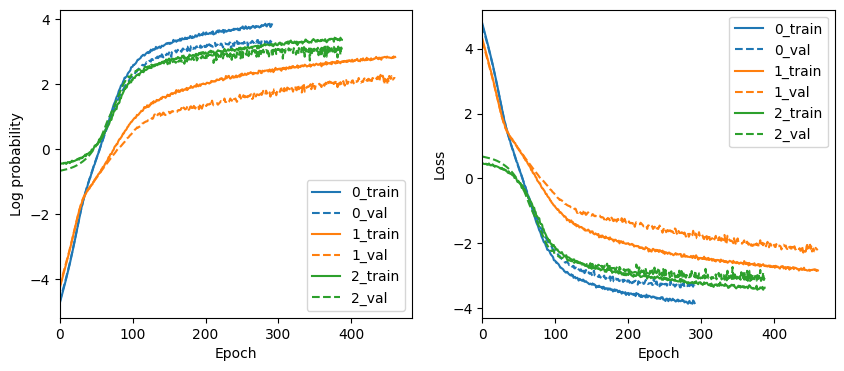

In [8]:
# summaries is a list of dictionaries with keys
# 'epochs_trained': somehow this is an array [0, number of eochs trained]
# 'best_validation_loss': somehow array of [-inf, min(validation_loss)]
# 'validation_loss', 'training_loss': arrays of shape (number of epochs trained,)
# 'epoch_durations_sec': array of shape (number of epochs trained,). I guess it's the time at each epoch?
# 'training_log_probs', 'validation_log_probs': arrays of shape (number of epochs trained,), log prob at each epoch
# 'best_validation_log_prob']: somehow array of [-inf, max(validation_log_probs)]

# plot train/validation loss
fig, ax = plt.subplots(1, 2, figsize=(10,4))
c = list(mcolors.TABLEAU_COLORS)

for i, m in enumerate(summaries):
    ax[0].plot(-1.0*np.array(m['training_loss']), ls='-', label=f"{i}_train", c=c[i])
    ax[0].plot(-1.0*np.array(m['validation_loss']), ls='--', label=f"{i}_val", c=c[i])
ax[0].set_xlim(0)
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Log probability')
ax[0].legend()

for i, m in enumerate(summaries):
    ax[1].plot(np.array(m['training_loss']), ls='-', label=f"{i}_train", c=c[i])
    ax[1].plot(np.array(m['validation_loss']), ls='--', label=f"{i}_val", c=c[i])
ax[1].set_xlim(0)
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

Looks abit overtrained tbh..

And how do I fish out information about the architecture and configuration of the NNs?

## Validation

  0%|          | 0/458 [00:00<?, ?it/s]

  0%|          | 0/145 [00:00<?, ?it/s]

  0%|          | 0/397 [00:00<?, ?it/s]

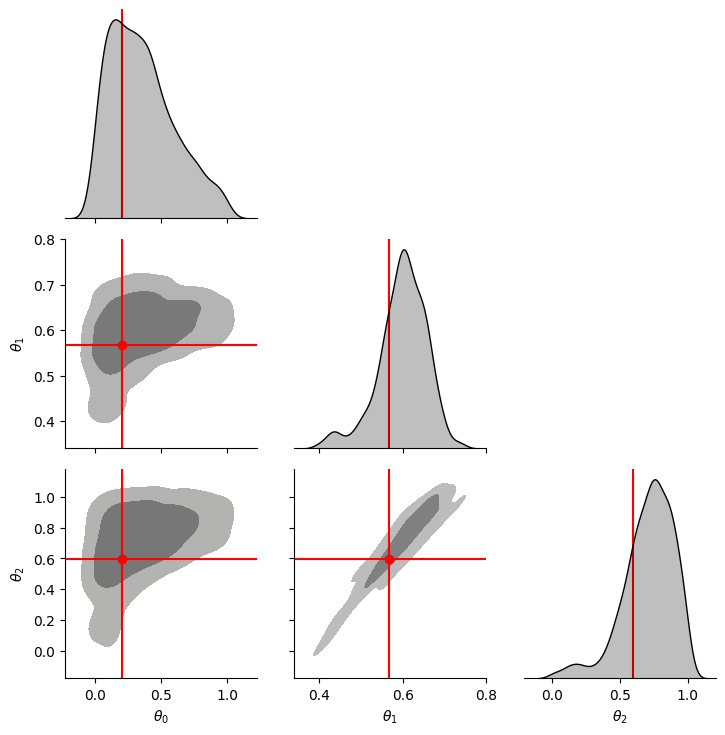

In [9]:
# use ltu-ili's built-in validation metrics to plot the posterior for this point
metric = PlotSinglePosterior(
    num_samples=1000, sample_method='direct', 
    labels=[f'$\\theta_{i}$' for i in range(3)]
)
fig = metric(
    posterior=posterior_ensemble,
    x_obs = x[ind], theta_fid=theta[ind],
    plot_kws=dict(fill=True)
)

The above plot shows the 68% and 95% confidence intervals of our ensemble posterior prediction. This shows that our model posterior is consistent with the true parameters for one datum. **However, how do we know that our model is good at predicting the full dataset?**


We can use the `PosteriorCoverage` object to measure various statistics about the posterior's performance on the whole dataset. Below, we ask `PosteriorCoverage` to compute:
 - `"coverage"`: the marginal, empirical coverage (P-P plot) of the model posteriors
 - `"histogram"`: the histogram of posterior ranks
 - `"predictions"`: classic true vs. predictions plots for all data points, with error bars
 - `"tarp"`: the multivariate, empirical coverage (P-P plot) of the model posteriors
 - `"logprob"`: the log probability of the true data under the model posterior

For explicit details on the definition and constructions of these plots, see Section 2.4 of [the LtU-ILI paper](https://arxiv.org/abs/2402.05137). The results of these metrics are shown, consecutively, in the output plots.

100%|██████████| 200/200 [00:08<00:00, 22.41it/s]
INFO:root:Mean logprob: 3.8924e+00Median logprob: 3.8970e+00
100%|██████████| 100/100 [00:01<00:00, 56.40it/s]
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


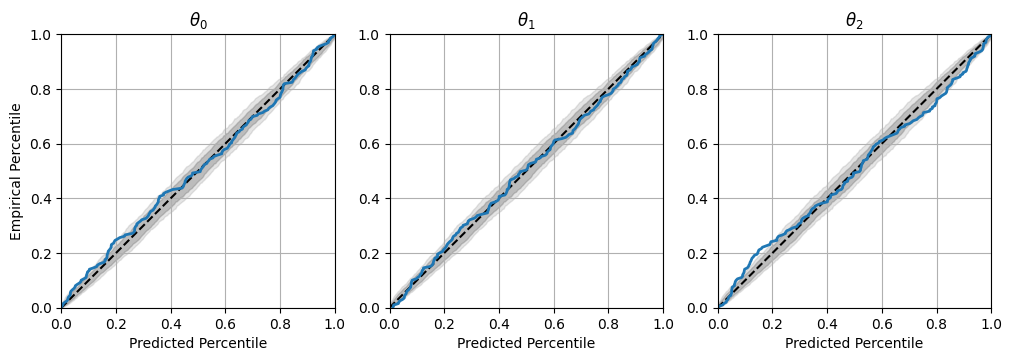

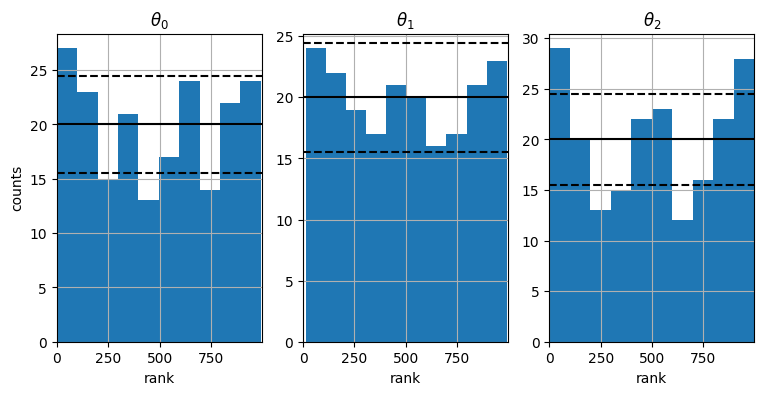

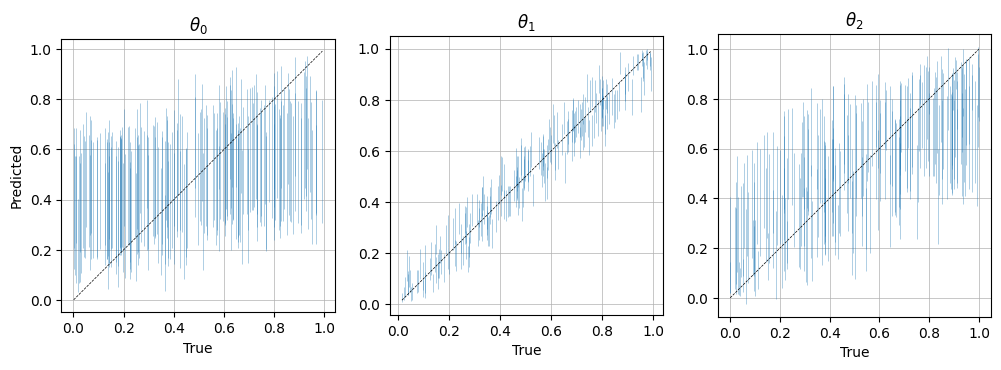

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


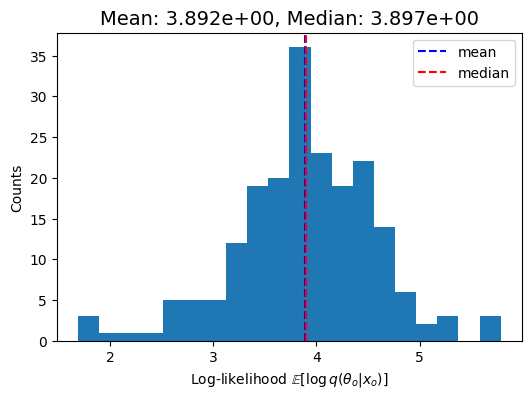

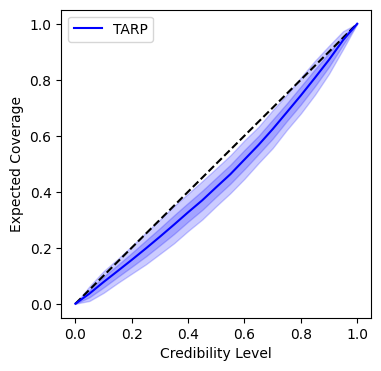

In [10]:
# Drawing samples from the ensemble posterior

metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct', 
    labels=[f'$\\theta_{i}$' for i in range(3)],
    plot_list = ["coverage", "histogram", "predictions", "tarp", "logprob"],
    out_dir=None
)

fig = metric(
    posterior=posterior_ensemble, # NeuralPosteriorEnsemble instance from sbi package
    x=x, theta=theta
)

In the ensemble model, it looks like our posteriors are well-calibrated when evaluated on marginal distributions, but slightly negatively biased in the multivariate TARP coverage.

Instead of computing validation metrics on the entire ensemble, we can examine the properties of the individual component networks. This allows us to diagnose problems with individual training runs.

We first look at the predictions from each component posterior for a single data point. The following plot uses `PlotSinglePosterior` to overplot contours for the same prediction by different models.

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

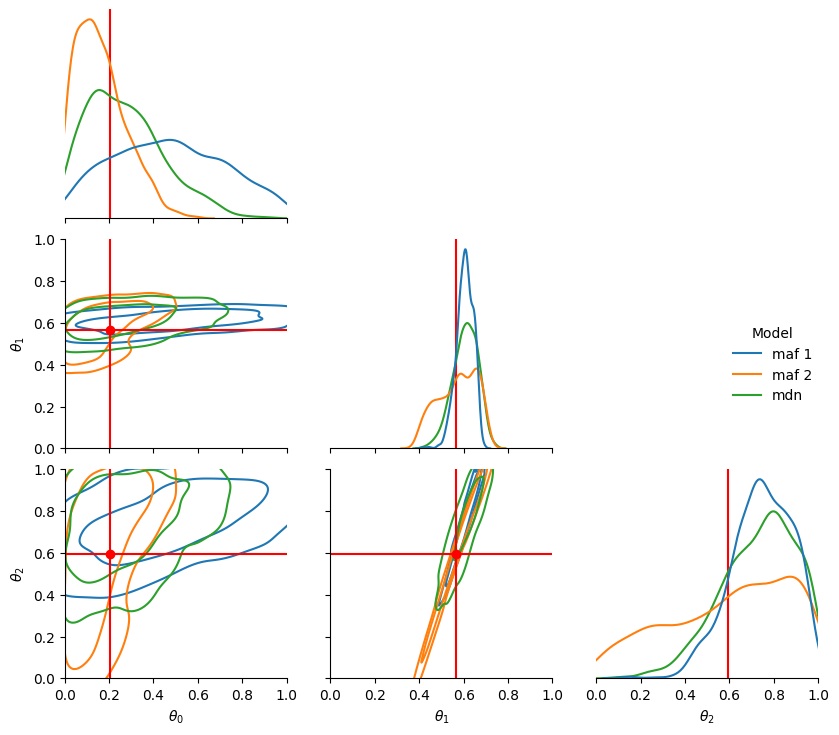

In [11]:
# use ltu-ili's built-in validation metrics to plot the posterior for this point
metric = PlotSinglePosterior(
    num_samples=1000, sample_method='direct', 
    labels=[f'$\\theta_{i}$' for i in range(3)]
)

# plot the posterior for model #1 (MAF)
fig = metric(
    posterior=posterior_ensemble.posteriors[0],
    x_obs = x[ind], theta_fid=theta[ind],
    name='maf 1',
    lower=np.zeros(3), upper=np.ones(3)
)

# plot the posterior for model #1 (MAF)
fig = metric(
    posterior=posterior_ensemble.posteriors[1],
    x_obs = x[ind], theta_fid=theta[ind],
    name='maf 2',
    lower=np.zeros(3), upper=np.ones(3),
    grid = fig
)

# overplot the posterior for model #3 (MDN)
fig = metric(
    posterior=posterior_ensemble.posteriors[2],
    x_obs = x[ind], theta_fid=theta[ind],
    name='mdn',
    lower=np.zeros(3), upper=np.ones(3),
    grid=fig  # overplot on the same figure
)

It looks like `mdn` models struggle to capture the strong degeneracies between $\theta_1$ and $\theta_2$, suggesting it is insufficiently flexible.

We can now compute separately `PosteriorCoverage` for each posterior in the ensemble.

100%|██████████| 100/100 [00:01<00:00, 55.09it/s]


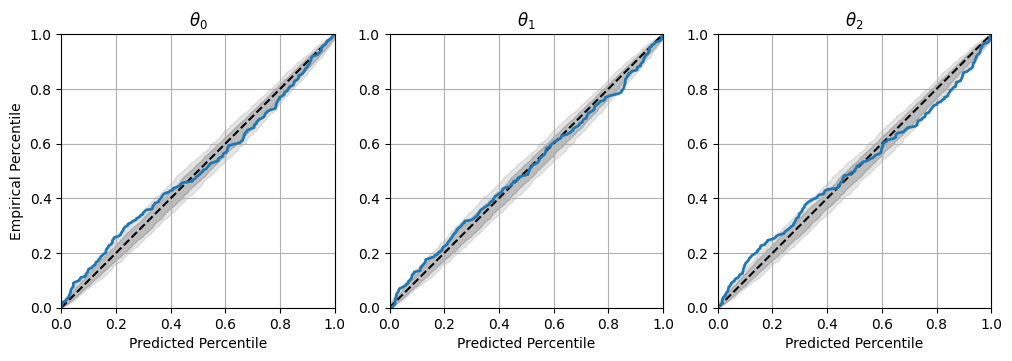

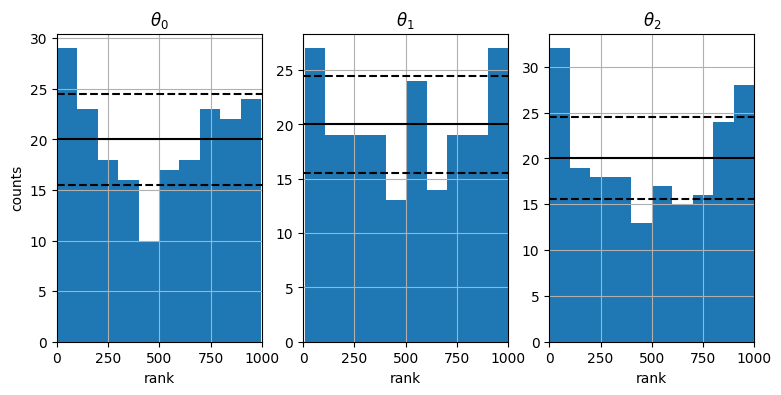

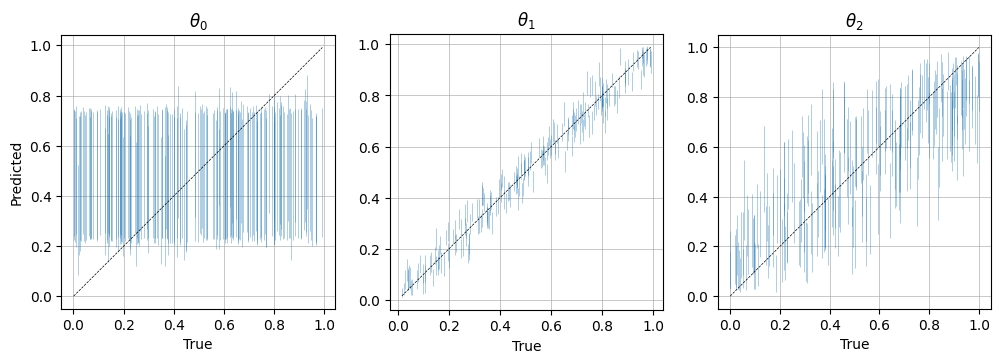

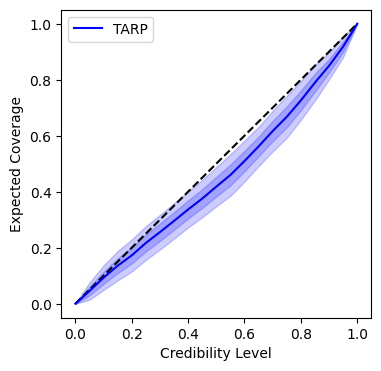

In [12]:
# Drawing samples for each posterior in the ensemble
# First the first MAF posterior
metric = PosteriorCoverage(num_samples=1000, 
    sample_method='direct', labels=[f'$\\theta_{i}$' for i in range(3)],
    plot_list = ["coverage", "histogram", "predictions", "tarp"])

fig = metric(
    posterior=posterior_ensemble.posteriors[0],
    x=x, theta=theta
)

100%|██████████| 100/100 [00:01<00:00, 60.75it/s]


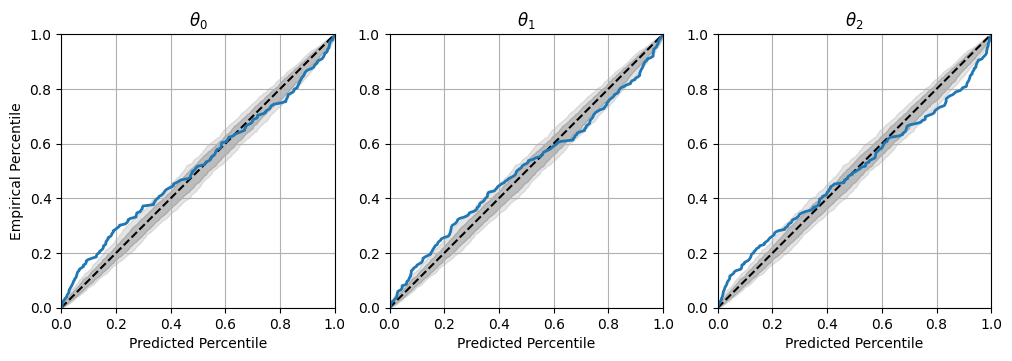

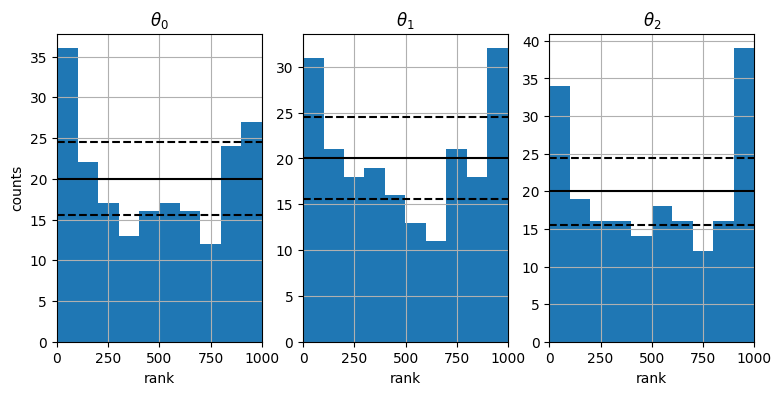

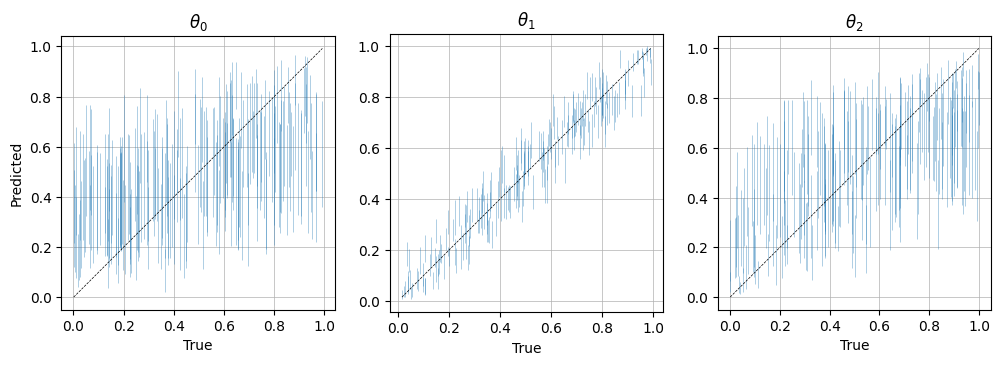

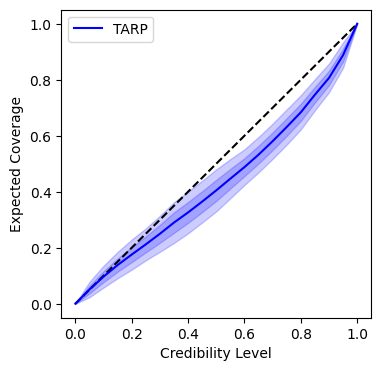

In [13]:
# Then for the MDN
fig = metric(
    posterior=posterior_ensemble.posteriors[2],
    x=x, theta=theta
)

From these results, we see that we are largely consistent and calibrated in the univariate coverage, with some slight negative bias shown in the multivariate coverage. It looks like the MAF model has slightly better constraints than the MDN model, while retaining the same calibration.